# Image processing

**Given:**  raw normalized colour image, coming from a depth sensor, raw greyscale image, show the same scene from the same point of view

**Find:** (x, y, angle) of each brick that lies flat on the table

In [418]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

Display functions:

In [419]:
def draw_detections(image_path, results, arrow_length=40, dot_radius=5,dot_color=(0, 0, 255), arrow_color=(0, 0, 255), thickness=2):
    """
    Overlay detection results on the original image.

    Parameters
    ----------
    image_path   : str   – path to the original image (raw or color)
    results      : list  – list of (cx, cy, angle_deg) tuples angle is the orientation of the longest side vs x-axis
    arrow_length : int   – half-length of the direction arrow in pixels
    dot_radius   : int   – radius of the center dot
    dot_color    : tuple – BGR color for the dot
    arrow_color  : tuple – BGR color for the arrow
    thickness    : int   – line thickness for the arrow

    Returns
    -------
    vis : np.ndarray – annotated image (BGR)
    """
    img = cv2.imread(image_path)
    vis = img.copy()

    for (cx, cy, angle_deg) in results:
        cx, cy = int(round(cx)), int(round(cy))

        # Convert angle to radians
        # angle_deg is the angle of the longest side w.r.t. the x-axis
        rad = math.radians(angle_deg)

        # Compute arrow tip and tail (centered on the plank center)
        dx = int(arrow_length * math.cos(rad))
        dy = int(arrow_length * math.sin(rad))

        pt_tail = (cx, cy)
        pt_tip  = (cx + dx, cy + dy)

        # Draw arrow
        cv2.arrowedLine(vis, pt_tail, pt_tip,
                        color=arrow_color,
                        thickness=thickness,
                        tipLength=0.3)

        # Draw center dot
        cv2.circle(vis, (cx, cy), dot_radius, dot_color, -1)

    return vis

def draw_points(image_path, points, dot_radius=5,dot_color=(0, 0, 255)):
    img = cv2.imread(image_path)
    vis = img.copy()

    for (cx, cy, angle_deg) in points:
        cx, cy = int(round(cx)), int(round(cy))
        pt_ = (cx, cy)
        # Draw center dot
        cv2.circle(vis, (cx, cy), dot_radius, dot_color, -1)
    return vis


def show_overlay(image_path, results, arrow_length=40, figsize=(14, 8), **kwargs):
    """
    Display the annotated image inline in a Jupyter notebook.

    Parameters
    ----------
    image_path   : str   – path to the original image
    results      : list  – list of (cx, cy, angle_deg) tuples
    arrow_length : int   – half-length of the direction arrow in pixels
    figsize      : tuple – matplotlib figure size
    **kwargs     : extra keyword args forwarded to draw_detections
    """
    #show point + arrow
    vis = draw_detections(image_path, results, arrow_length=arrow_length, **kwargs)
    
    #show points only
    #vis= draw_points(image_path, results, **kwargs)
    
    # OpenCV loads BGR, matplotlib expects RGB
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(vis_rgb)
    ax.axis('off')
    ax.set_title(f"{len(results)} plank(s) detected", fontsize=13)
    plt.tight_layout()
    plt.show()

    return vis

## Define img to use:

In [420]:
#images to use
#color img:
my_color_img='Test_images12_raw_img_work_with_them\\normalized_color11.png'
#grey img:
my_grey_img='Test_images12_raw_img_work_with_them\\raw_image11.png'

normalized_color img processing

In [421]:
#Extract hue as depth proxy
color_img = cv2.imread(my_color_img)
hsv = cv2.cvtColor(color_img, cv2.COLOR_BGR2HSV)
hue= hsv[:, :, 0]   #depth map, 0–179 in OpenCV

#CLAHE on the hue channel (for local contrast)
clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
hue_eq    = clahe.apply(hue)

#Blur to reduce noise
blurred   = cv2.GaussianBlur(hue_eq, (3, 3), 0)

#Canny on the hue channel — thresholds likely need to be different
#from grayscale since hue is 0-179, not 0-255
#edges = cv2.Canny(blurred, threshold1=10, threshold2=40)

#or, instead of Canny, using Sobel:

sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(sobelx**2 + sobely**2)

# Normalize and threshold to get binary edge image
magnitude = np.uint8(255 * magnitude / magnitude.max())
_, edges= cv2.threshold(magnitude, 30, 255, cv2.THRESH_BINARY)  # tune 30

#end of sobel

#Close gaps --> no visible improvement
kernel       = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
edges_closed = cv2.dilate(edges, kernel, iterations=1)
edges_closed=edges

In [422]:
img_grey = cv2.imread(my_grey_img, cv2.IMREAD_GRAYSCALE)

#increase contrast (to avoid prblms in darker regions)
#clahe = cv2.createCLAHE(clipLimit=2.3, tileGridSize=(8, 8))  # tune clipLimit: 1.0–4.0
clahe = cv2.createCLAHE(clipLimit=2, tileGridSize=(4, 4))  # tune clipLimit: 1.0–4.0
img_eq = clahe.apply(img_grey)
#edges_grey  = cv2.Canny(img1, threshold1=30, threshold2=100)

#gaussian filter
blurred = cv2.GaussianBlur(img_eq, (11, 11), 0) #(5,5)

#edge detection, works better with manual set thresholds
#median  = np.median(blurred)
#lower   = int(max(0,   0.66 * median))
#upper   = int(min(255, 1.33 * median))
#edges   = cv2.Canny(blurred, lower, upper)
#print(lower, upper)
edges_grey = cv2.Canny(blurred, threshold1=30, threshold2=100)#30, 100

#close gaps in the edges to try to get rectangular shape --> not useful
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)) #tune size: try 3,5,7
edges_grey = cv2.dilate(edges_grey, kernel, iterations=1)     # try iterations=2 if gaps persist


In [423]:
edges_closed=edges_grey+edges_closed

In [424]:
#Find contours
contours, _  = cv2.findContours(edges_closed, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

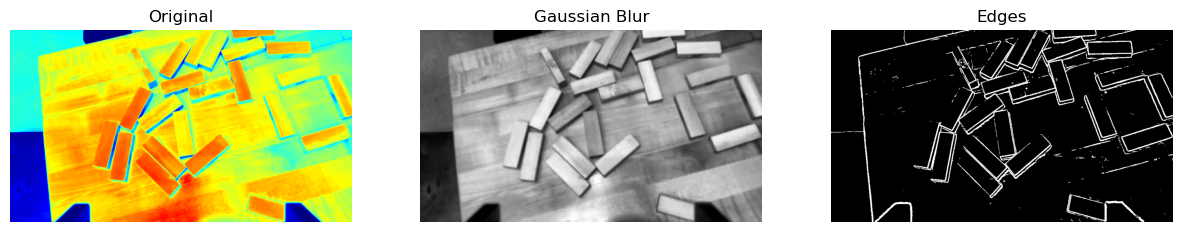

True

In [425]:
fig, ax = plt.subplots(1, 3, figsize=(15, 7))

# Original Image
ax[0].imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original')
ax[0].axis('off')

# Blurred Image
ax[1].imshow(blurred, cmap='gray')
ax[1].set_title('Gaussian Blur')
ax[1].axis('off')

ax[2].imshow(edges, cmap='gray')
ax[2].set_title('Edges')
ax[2].axis('off')

plt.show()

#save 'edges'
cv2.imwrite('detected_edges_img.png', edges_closed)

In [426]:
results = []
print('Raw detected features fulfilling area condition:')

for cnt in contours:
    area = cv2.contourArea(cnt)
#    if area < 3000:  # tune this
    if area < 8000:   # only skip tiny noise <=> if area < XXX, don't consider it, else consider it
        continue
        
    rect = cv2.minAreaRect(cnt)
    (cx, cy), (w, h), angle = rect
    if w < h:
        w, h = h, w
        angle += 90
        
    aspect = w / h if h > 0 else 0
    hull = cv2.convexHull(cnt)
    solidity = area / cv2.contourArea(hull)
    
    print(f"cx={cx:.0f} cy={cy:.0f} | area={area:.0f} | "
          f"aspect={aspect:.2f} | solidity={solidity:.2f} | angle={angle:.1f}°")
    
    #if 1.5 < aspect < 7.0 and 0.65 < solidity < 0.95:  # tune thresholds
    if 2.0 < aspect < 5.0:
        results.append((cx, cy, angle))

#remove duplicates: points that are very close to each other
to_remove=[]
for i in range(0, len(results)):
    for j in range(i+1, len(results)):
        if (results[i][0]-results[j][0]) < 10 and (results[i][1]-results[j][1]) < 10:
            to_remove.append(results[j])
for elem in to_remove:
    if elem in results:
        results.remove(elem)

Raw detected features fulfilling area condition:
cx=1029 cy=679 | area=10918 | aspect=3.16 | solidity=0.51 | angle=9.4°
cx=737 cy=467 | area=9026 | aspect=3.21 | solidity=0.97 | angle=-40.4°
cx=1183 cy=403 | area=9264 | aspect=3.21 | solidity=0.97 | angle=-17.7°
cx=1186 cy=402 | area=11071 | aspect=3.01 | solidity=0.95 | angle=-17.9°
cx=560 cy=310 | area=8082 | aspect=3.31 | solidity=0.96 | angle=-36.2°
cx=739 cy=184 | area=11390 | aspect=1.27 | solidity=0.71 | angle=-18.4°
cx=567 cy=181 | area=12688 | aspect=1.67 | solidity=0.48 | angle=85.0°
cx=653 cy=225 | area=117779 | aspect=1.62 | solidity=0.36 | angle=-49.4°


In [427]:
results

[(1029.058349609375, 679.049560546875, 9.363449096679688),
 (736.7431640625, 466.66839599609375, -40.36453628540039),
 (1182.9991455078125, 403.0640563964844, -17.700428009033203),
 (560.4251708984375, 309.76617431640625, -36.15818405151367)]

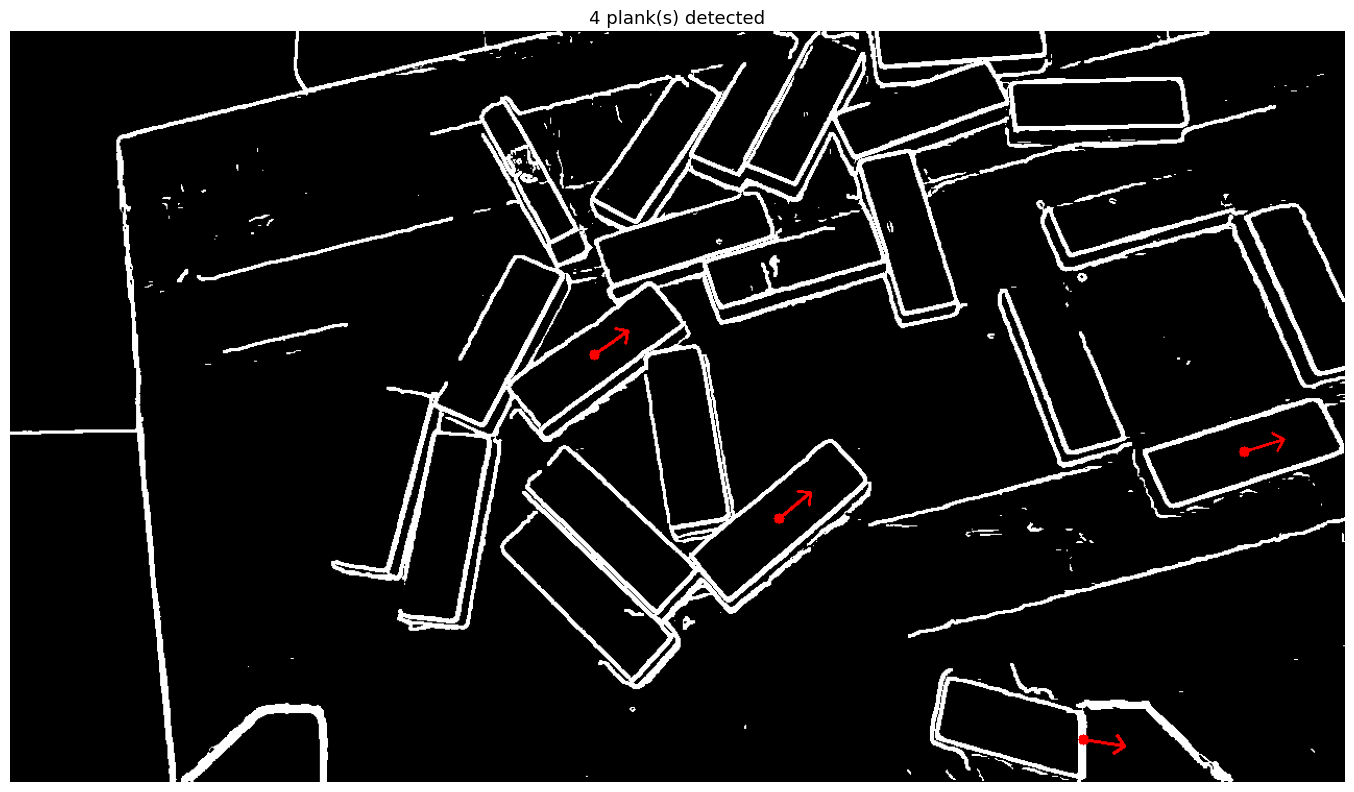

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [428]:
show_overlay('detected_edges_img.png', results)

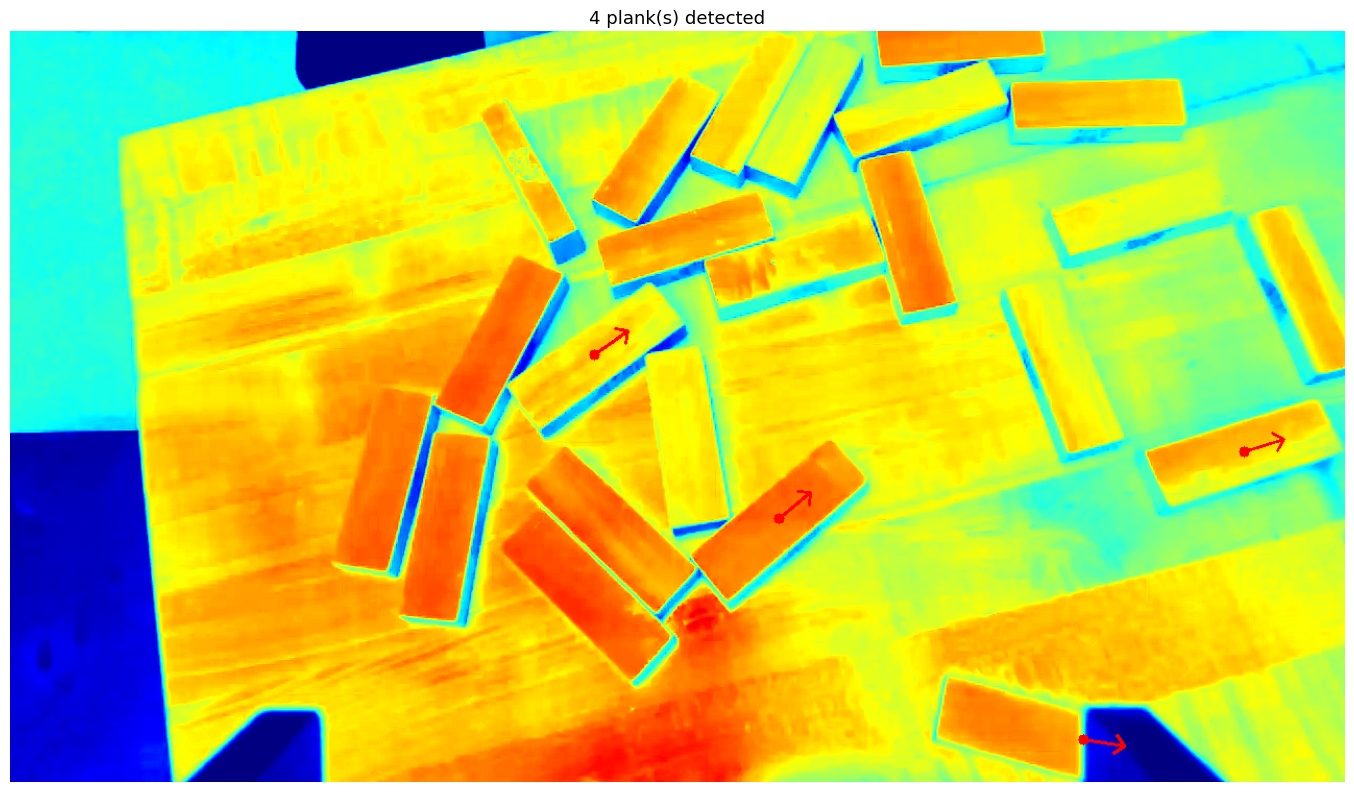

array([[[242, 255,  14],
        [242, 255,  14],
        [242, 255,  14],
        ...,
        [255, 252,   0],
        [255, 248,   0],
        [255, 248,   0]],

       [[242, 255,  14],
        [242, 255,  14],
        [242, 255,  14],
        ...,
        [255, 252,   0],
        [255, 248,   0],
        [255, 248,   0]],

       [[238, 255,  18],
        [238, 255,  18],
        [238, 255,  18],
        ...,
        [255, 252,   0],
        [255, 248,   0],
        [255, 248,   0]],

       ...,

       [[212,   0,   0],
        [212,   0,   0],
        [212,   0,   0],
        ...,
        [ 74, 255, 182],
        [ 74, 255, 182],
        [ 66, 255, 190]],

       [[212,   0,   0],
        [212,   0,   0],
        [212,   0,   0],
        ...,
        [ 74, 255, 182],
        [ 74, 255, 182],
        [ 66, 255, 190]],

       [[212,   0,   0],
        [212,   0,   0],
        [212,   0,   0],
        ...,
        [ 74, 255, 182],
        [ 74, 255, 182],
        [ 74, 255, 182]]

In [429]:
show_overlay(my_color_img, results)

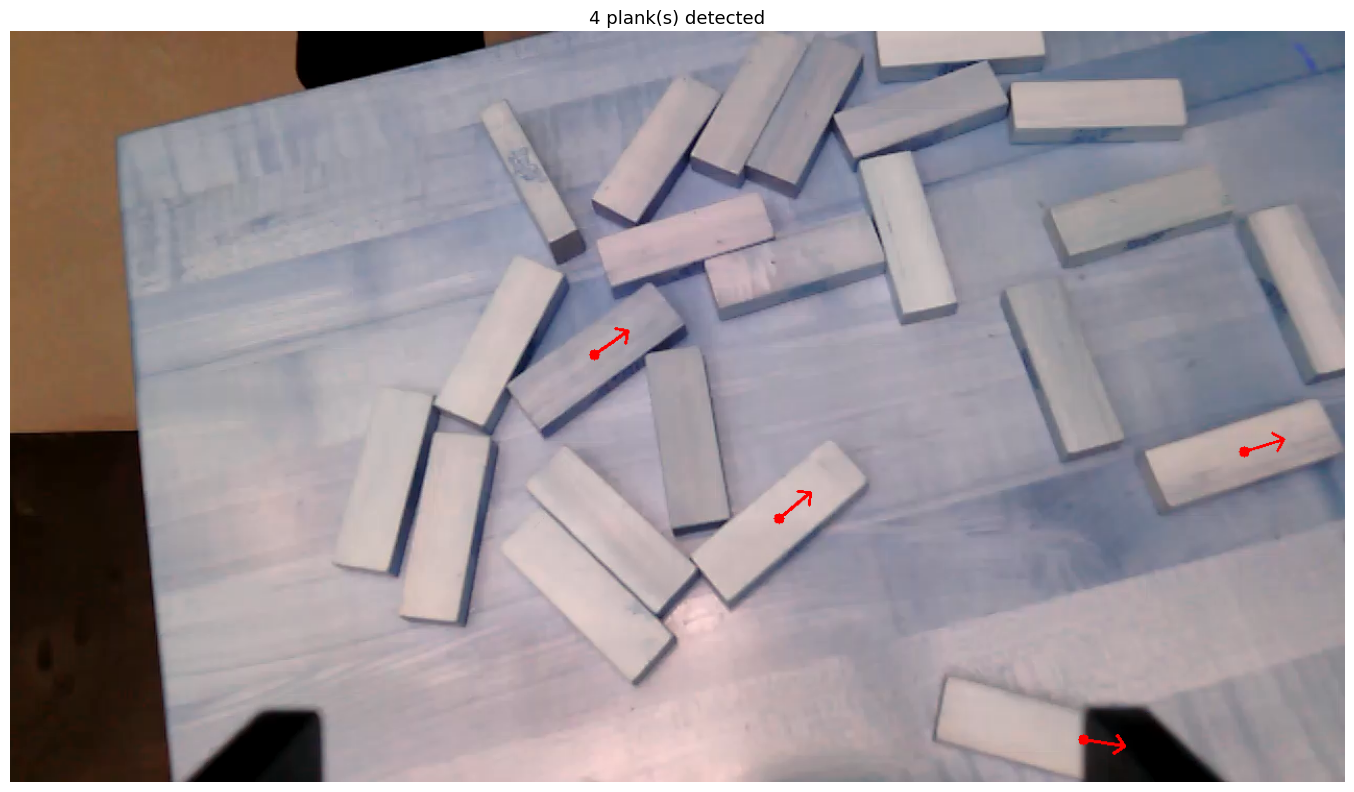

array([[[ 50,  92, 133],
        [ 50,  92, 133],
        [ 50,  92, 133],
        ...,
        [123,  97,  80],
        [122,  96,  79],
        [122,  96,  79]],

       [[ 50,  92, 133],
        [ 50,  92, 133],
        [ 50,  92, 133],
        ...,
        [123,  97,  80],
        [122,  96,  79],
        [122,  96,  79]],

       [[ 51,  93, 134],
        [ 51,  93, 134],
        [ 51,  93, 134],
        ...,
        [123,  97,  80],
        [122,  96,  79],
        [122,  96,  79]],

       ...,

       [[  5,  19,  32],
        [  5,  19,  32],
        [  5,  19,  32],
        ...,
        [141, 138, 146],
        [141, 138, 146],
        [143, 140, 148]],

       [[  5,  19,  32],
        [  5,  19,  32],
        [  5,  19,  32],
        ...,
        [141, 138, 146],
        [141, 138, 146],
        [143, 140, 148]],

       [[  5,  19,  32],
        [  5,  19,  32],
        [  5,  19,  32],
        ...,
        [141, 138, 146],
        [141, 138, 146],
        [141, 138, 146]]

In [430]:
show_overlay(my_grey_img, results)